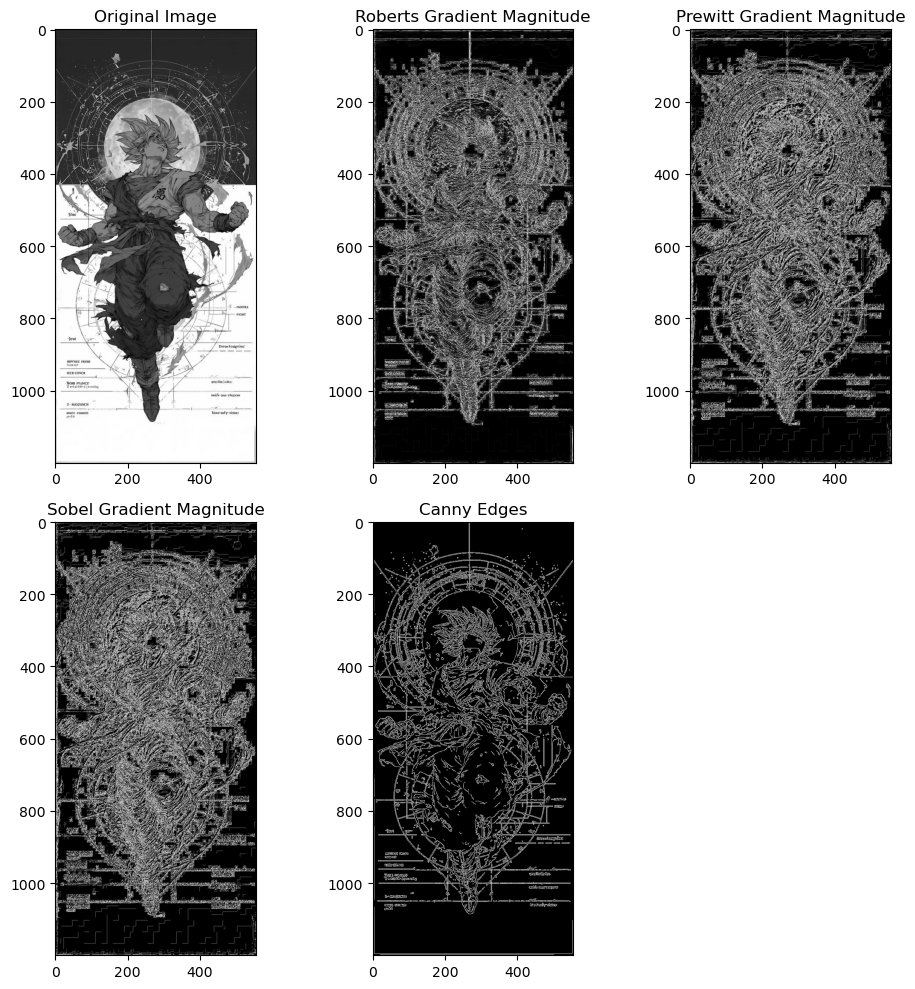

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('goku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Roberts
robertx = np.array([[-1, 0], [0, 1]])
roberty = np.array([[0, -1], [1, 0]])
robx_img = cv2.filter2D(gray, -1, robertx)   
roby_img = cv2.filter2D(gray, -1, roberty)  
rob_grad = np.sqrt(robx_img**2 + roby_img**2)
rob_grad_dir = np.arctan2(roby_img, robx_img)

# Prewitt
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
prex_img = cv2.filter2D(gray, -1, prewitt_x)
prey_img = cv2.filter2D(gray, -1, prewitt_y)
prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)
prewitt_dir = np.arctan2(prey_img, prex_img)

# Sobel
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
sobelx_img = cv2.filter2D(gray, -1, sobel_x)
sobely_img = cv2.filter2D(gray, -1, sobel_y)
sobel_mag = np.sqrt(sobelx_img**2 + sobely_img**2)
sobel_dir = np.arctan2(sobely_img, sobelx_img)

# Canny
canny_img = cv2.Canny(gray, 100, 200)   # ✅ umbral alto > umbral bajo (recomendado)

# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(2, 3, 1), plt.imshow(gray, cmap='gray'), plt.title('Original Image')
plt.subplot(2, 3, 2), plt.imshow(rob_grad, cmap='gray'), plt.title('Roberts Gradient Magnitude')
plt.subplot(2, 3, 3), plt.imshow(prewitt_mag, cmap='gray'), plt.title('Prewitt Gradient Magnitude')
plt.subplot(2, 3, 4), plt.imshow(sobel_mag, cmap='gray'), plt.title('Sobel Gradient Magnitude')
plt.subplot(2, 3, 5), plt.imshow(canny_img, cmap='gray'), plt.title('Canny Edges')
plt.tight_layout()
plt.show()

sobel

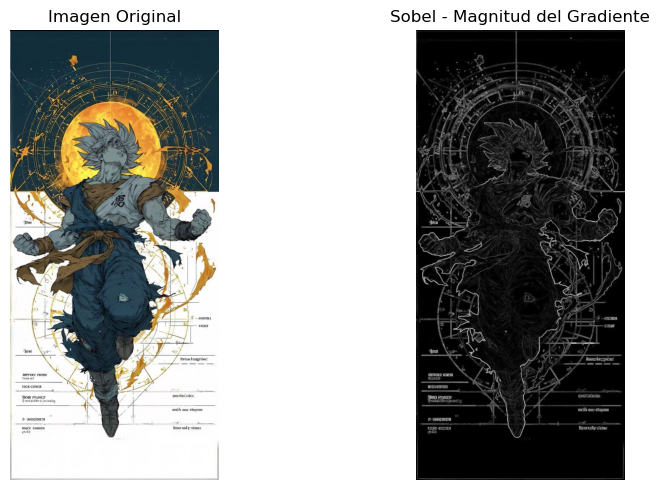

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    return mag

img = cv2.imread('goku.jpg')


resultado = filtro_sobel(img)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # BGR→RGB para matplotlib
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resultado, cmap='gray')
plt.title('Sobel - Magnitud del Gradiente')
plt.axis('off')

plt.tight_layout()
plt.show()


sobel mejorado

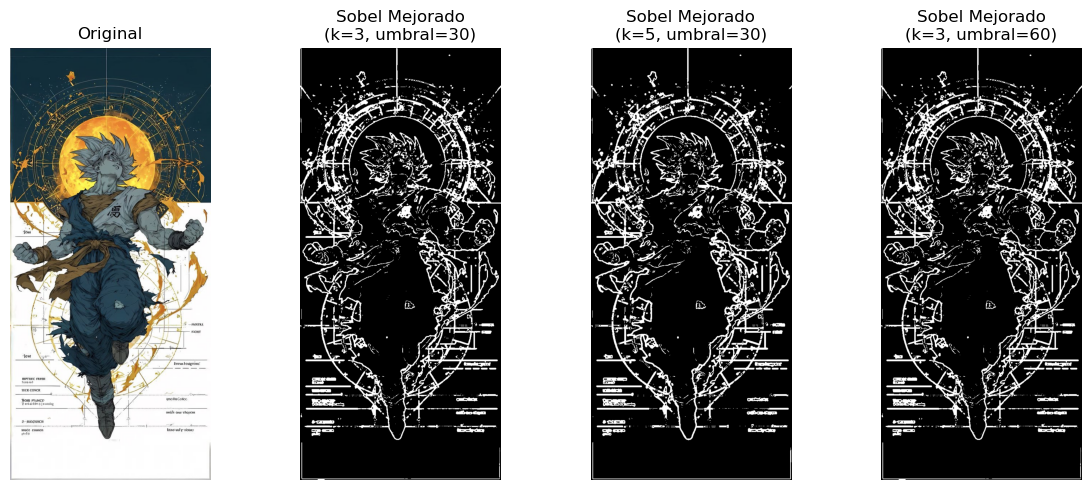

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img, kernel_size=3, umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gris = cv2.GaussianBlur(img_gris, (3, 3), 0)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=kernel_size)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=kernel_size)

    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _, bordes = cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel_m = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_m)
    return bordes

img = cv2.imread('goku.jpg')

resultado_default  = filtro_sobel_mejorado(img)
resultado_k5       = filtro_sobel_mejorado(img, kernel_size=5)
resultado_umbral60 = filtro_sobel_mejorado(img, umbral=60)


plt.figure(figsize=(12, 5))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(resultado_default, cmap='gray')
plt.title('Sobel Mejorado\n(k=3, umbral=30)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(resultado_k5, cmap='gray')
plt.title('Sobel Mejorado\n(k=5, umbral=30)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(resultado_umbral60, cmap='gray')
plt.title('Sobel Mejorado\n(k=3, umbral=60)')
plt.axis('off')

plt.tight_layout()
plt.show()

otro rapidito 

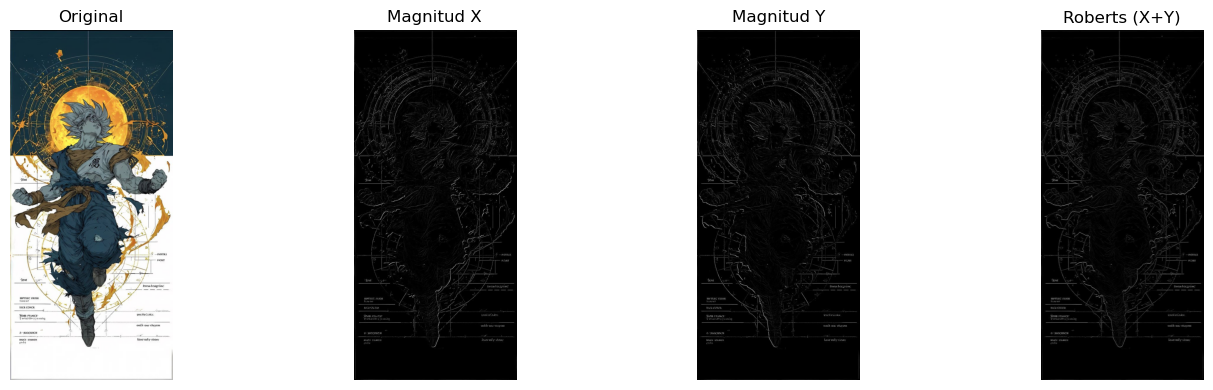

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    robertx = np.array([[-1, 0], [0, 1]], dtype=np.float32)
    roberty = np.array([[0, -1], [1, 0]], dtype=np.float32)
    r_x = cv2.filter2D(img_gris, -1, robertx)
    r_y = cv2.filter2D(img_gris, -1, roberty)
    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    return r_x, r_y, roberts

img = cv2.imread('goku.jpg')

r_x, r_y, roberts = filtro_roberts(img)

mag_x = cv2.normalize(r_x.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
mag_y = cv2.normalize(r_y.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mag_x, cmap='gray')
plt.title('Magnitud X')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(mag_y, cmap='gray')
plt.title('Magnitud Y')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(roberts, cmap='gray')
plt.title('Roberts (X+Y)')
plt.axis('off')

plt.tight_layout()
plt.show()